# step:1 Import libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

# step:2 Load dataset

In [ ]:
df = pd.read_csv("online_shoppers_intention.csv")

# step:3 EDA

In [ ]:
df.shape

(12330, 18)

In [ ]:
df.columns

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType',
       'Weekend', 'Revenue'],
      dtype='object')

In [ ]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [ ]:
df[df["Revenue"]== True]

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
65,3,87.833333,0,0.00,27,798.333333,0.000000,0.012644,22.916036,0.8,Feb,2,2,3,1,Returning_Visitor,False,True
76,10,1005.666667,0,0.00,36,2111.341667,0.004348,0.014493,11.439412,0.0,Feb,2,6,1,2,Returning_Visitor,False,True
101,4,61.000000,0,0.00,19,607.000000,0.000000,0.026984,17.535959,1.0,Feb,1,1,7,4,Returning_Visitor,True,True
188,9,111.500000,1,48.50,49,1868.819697,0.000000,0.020709,1.706015,0.0,Mar,2,2,7,2,Returning_Visitor,False,True
196,2,56.000000,1,144.00,67,2563.783333,0.000000,0.005797,19.342650,0.0,Mar,2,2,4,2,New_Visitor,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12272,6,133.466667,0,0.00,44,2664.445833,0.002041,0.010884,97.860836,0.0,Nov,2,2,1,3,Returning_Visitor,True,True
12276,7,139.575000,0,0.00,30,986.500000,0.000000,0.011429,36.392861,0.0,Dec,2,10,1,2,New_Visitor,False,True
12311,1,0.000000,2,211.25,144,4627.489571,0.001361,0.020664,0.000000,0.0,Nov,2,2,1,2,Returning_Visitor,False,True
12312,7,150.357143,1,9.00,221,11431.001240,0.011149,0.021904,1.582473,0.0,Nov,2,5,1,2,Returning_Visitor,True,True


In [ ]:
df[df["Revenue"]== False]

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.000000,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.000000,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.000000,0.0,Feb,3,3,1,4,Returning_Visitor,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12325,3,145.0,0,0.0,53,1783.791667,0.007143,0.029031,12.241717,0.0,Dec,4,6,1,1,Returning_Visitor,True,False
12326,0,0.0,0,0.0,5,465.750000,0.000000,0.021333,0.000000,0.0,Nov,3,2,1,8,Returning_Visitor,True,False
12327,0,0.0,0,0.0,6,184.250000,0.083333,0.086667,0.000000,0.0,Nov,3,2,1,13,Returning_Visitor,True,False
12328,4,75.0,0,0.0,15,346.000000,0.000000,0.021053,0.000000,0.0,Nov,2,2,3,11,Returning_Visitor,False,False


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [ ]:
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


In [ ]:
df.isnull().sum()

,0
Administrative,0
Administrative_Duration,0
Informational,0
Informational_Duration,0
ProductRelated,0
ProductRelated_Duration,0
BounceRates,0
ExitRates,0
PageValues,0
SpecialDay,0


In [ ]:
df.duplicated().sum()

np.int64(125)

In [ ]:
df.drop_duplicates(inplace=True)

# step:3 Train-test-split

In [ ]:
X = df.drop("Revenue",axis=1)
y = df["Revenue"]
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# step:4 Data Visualizations

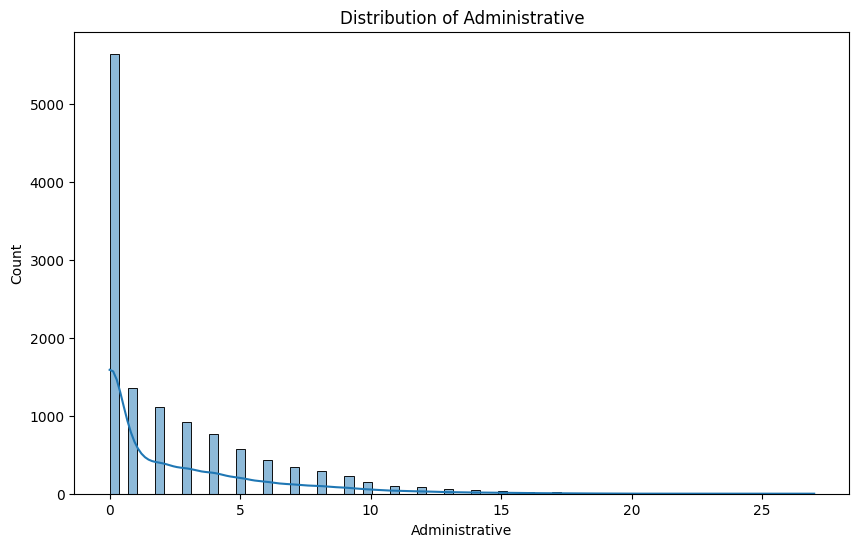

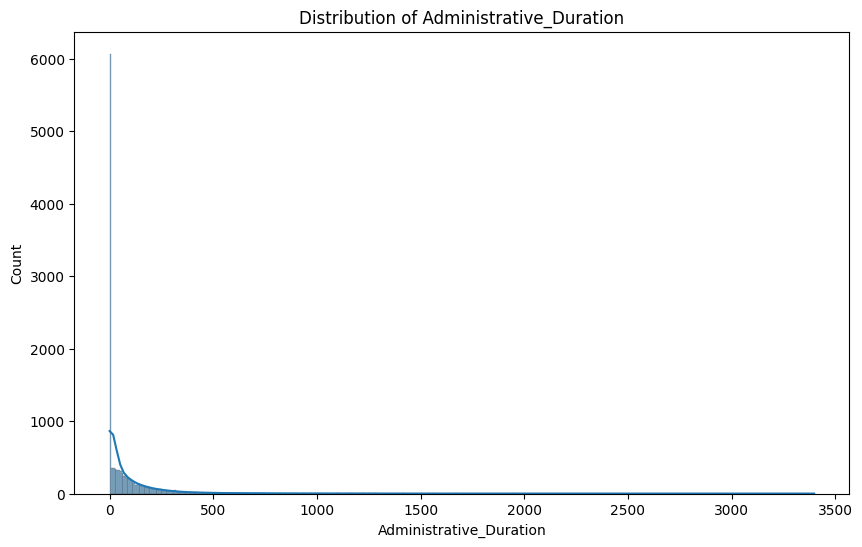

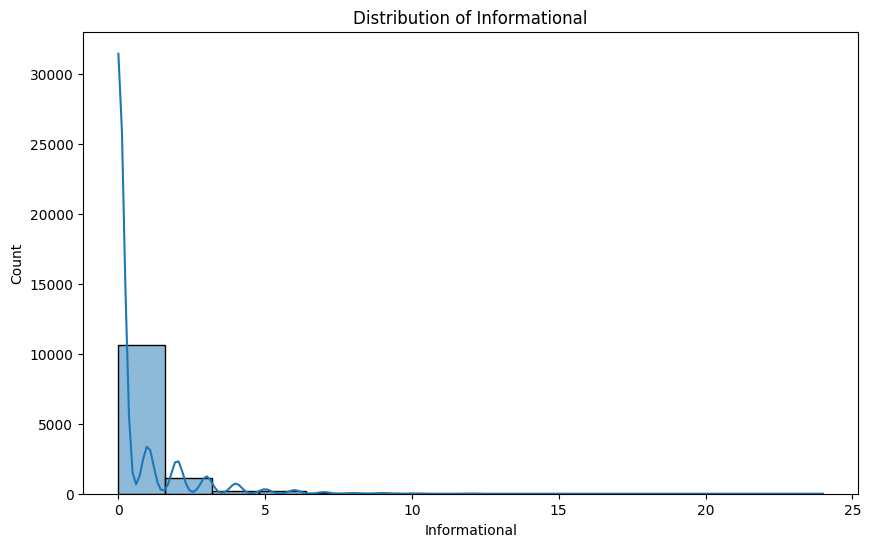

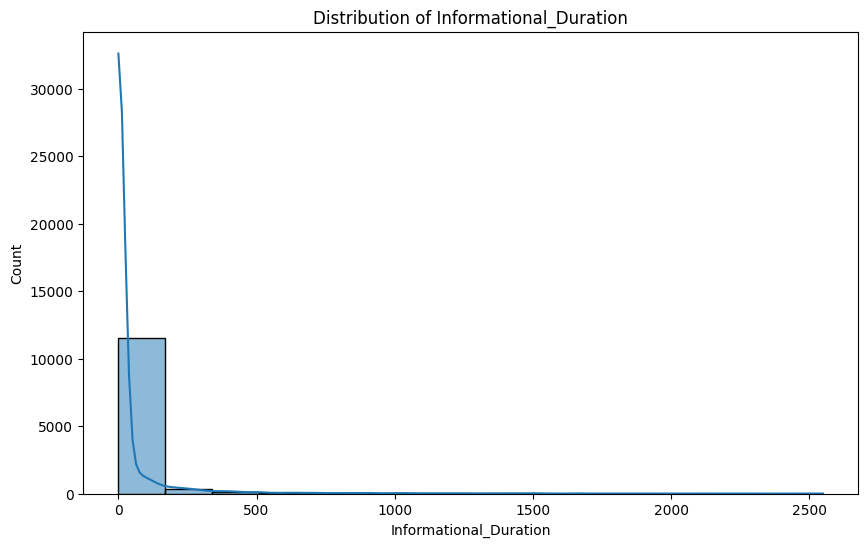

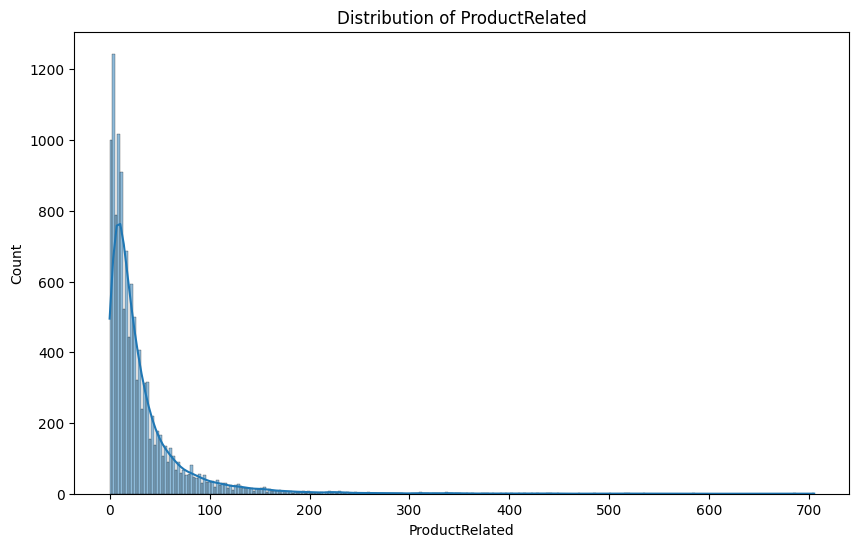

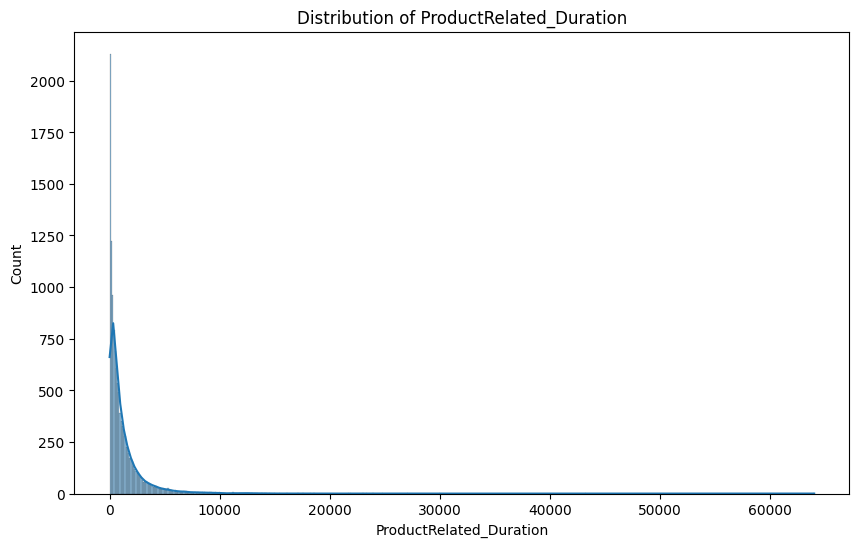

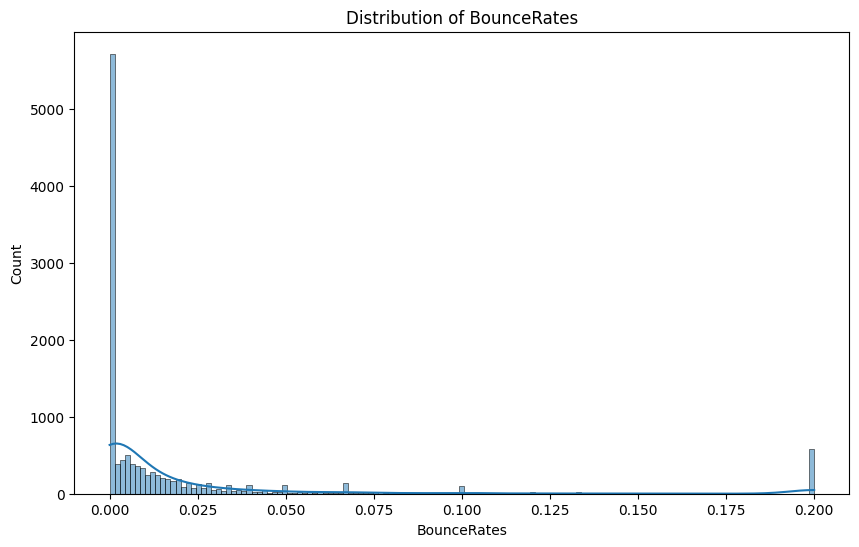

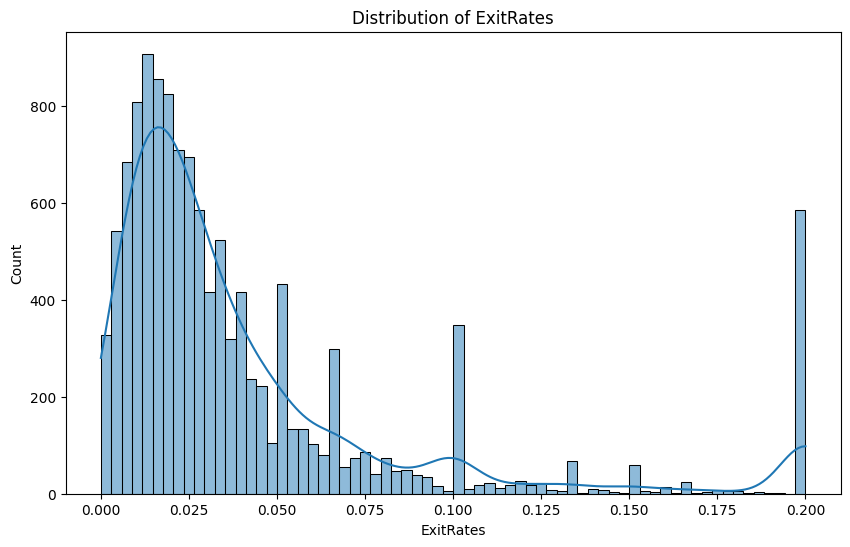

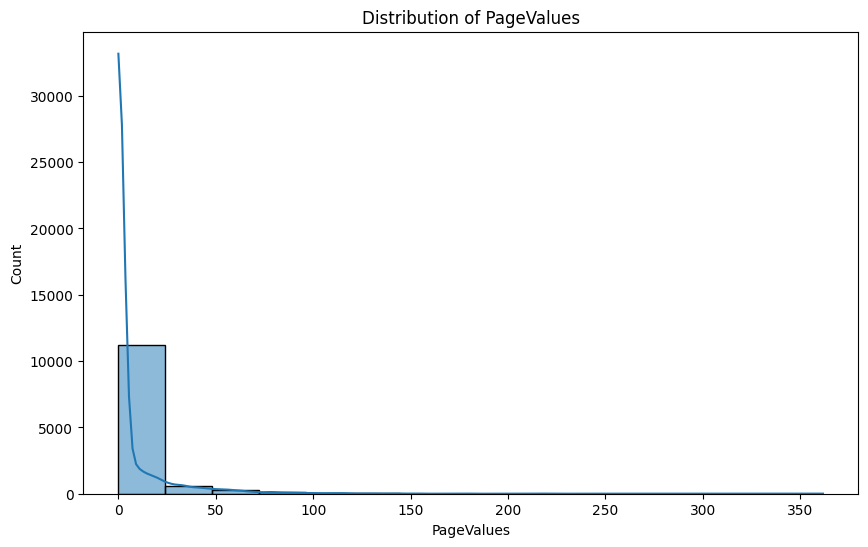

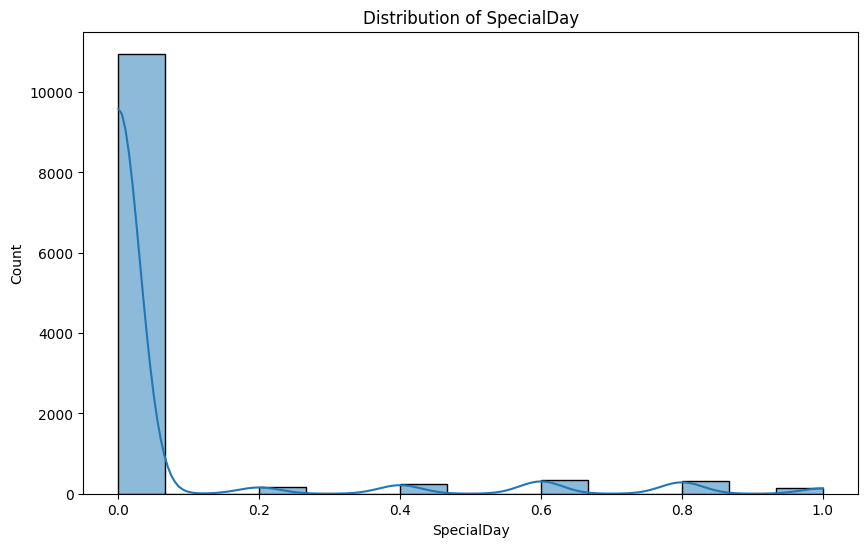

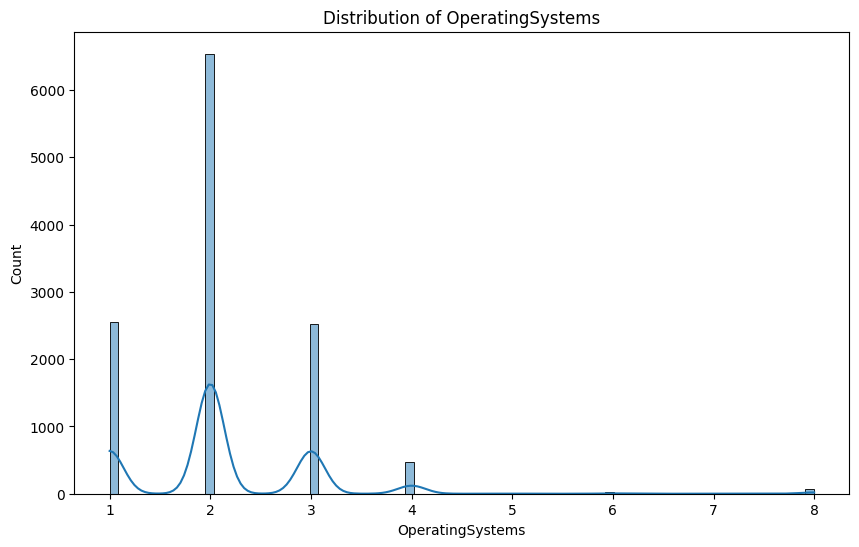

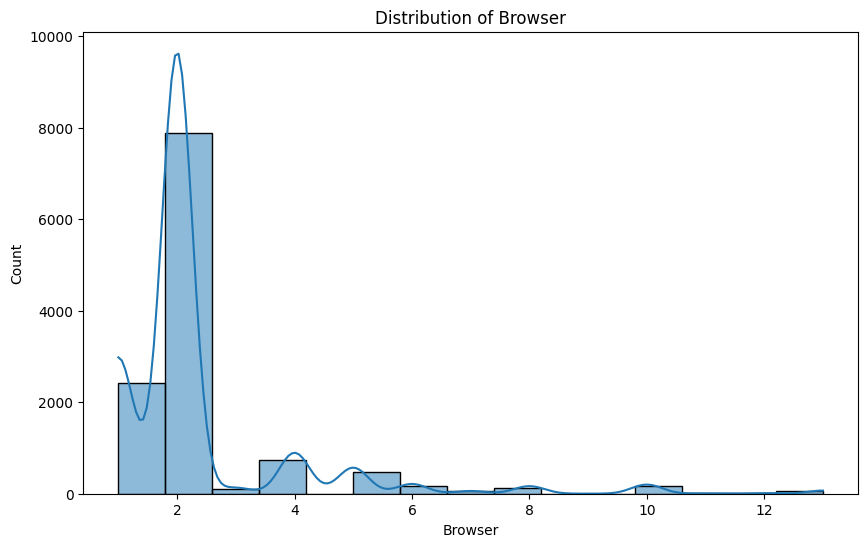

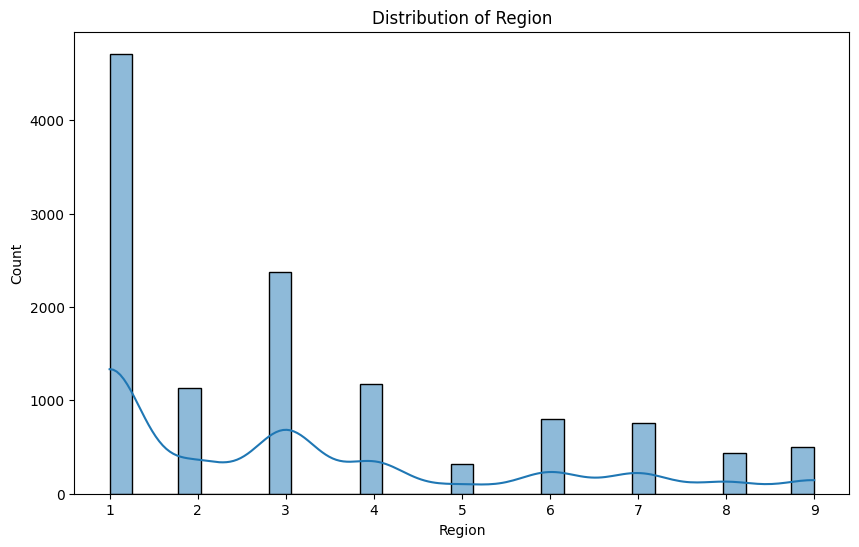

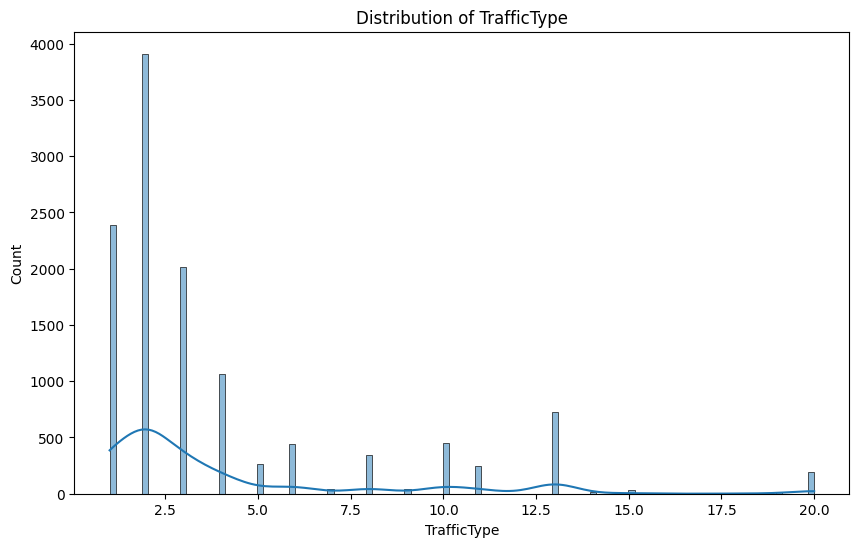

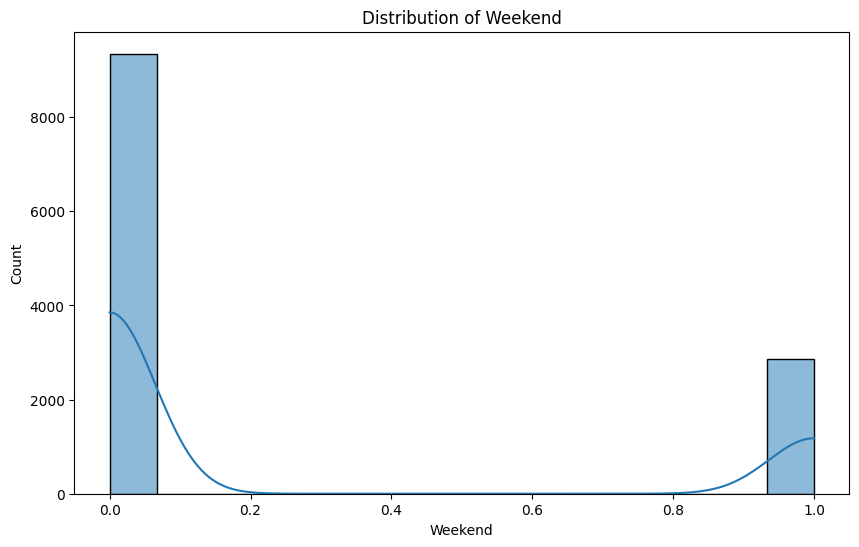

In [ ]:
numerical_cols = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues",
    "SpecialDay",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType",
    "Weekend"
]
for col in numerical_cols:
  plt.figure(figsize=(10,6))
  sns.histplot(data=df,x=col,kde=True)
  plt.title(f"Distribution of {col}")
  plt.show()

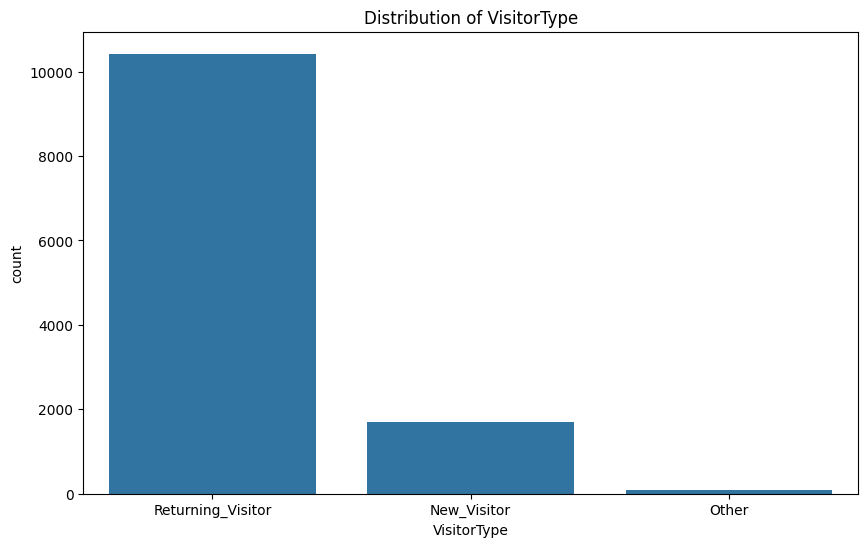

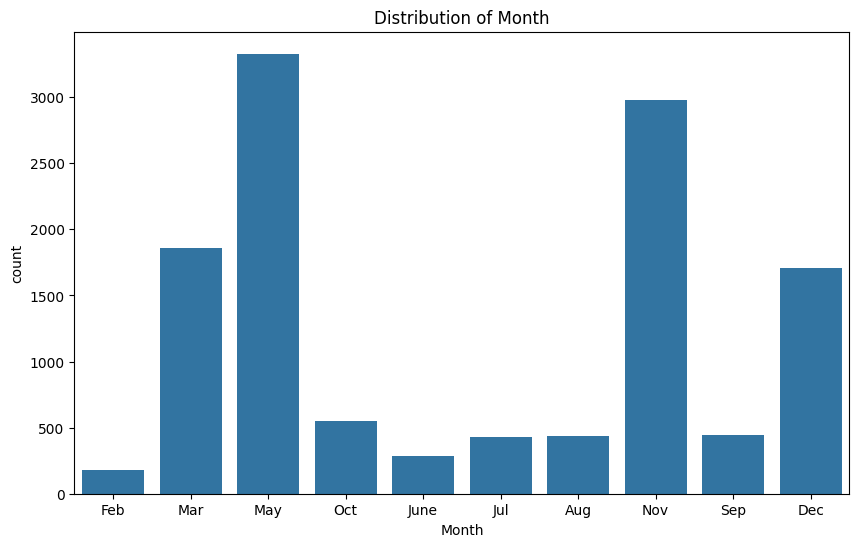

In [ ]:
categorical_cols = [
    "VisitorType",
    "Month"
]
for col in categorical_cols:
  plt.figure(figsize=(10,6))
  sns.countplot(data=df,x=col)
  plt.title(f"Distribution of {col}")
  plt.show()

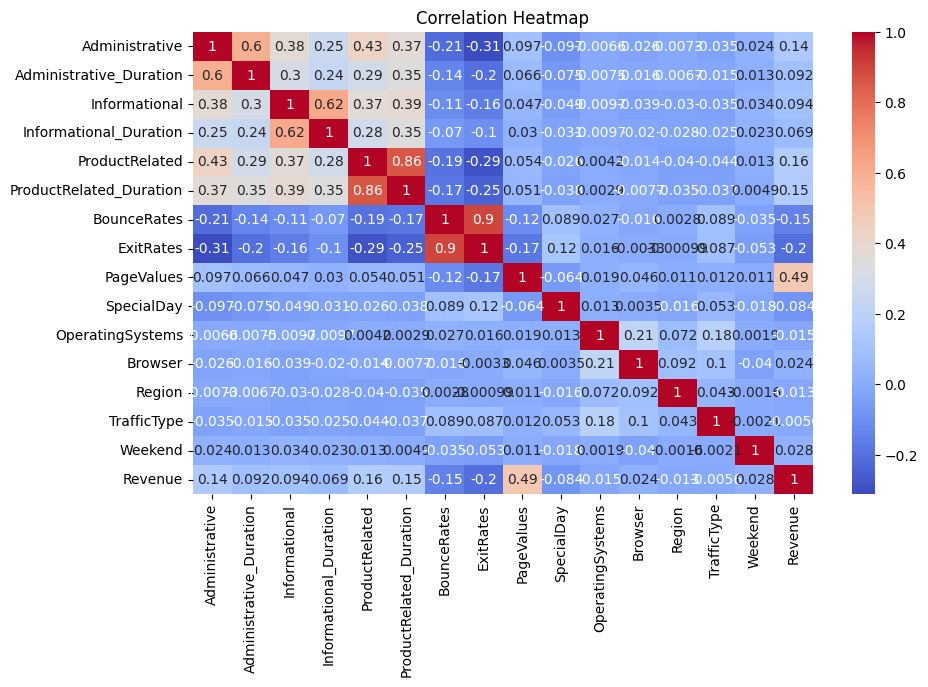

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df[numerical_cols + ["Revenue"]].corr(),annot=True,cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# step:5 Checking multicollinearity

In [ ]:
numerical_cols =[
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues",
    "SpecialDay",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType",
    "Weekend"
]
x = df[numerical_cols].copy()
x["Weekend"] = x["Weekend"].astype(int)
vif_data = pd.DataFrame()
vif_data["Feature"] = x.columns
vif_data["VIF"] = [variance_inflation_factor(x.values,i) for i in range(x.shape[1])]
print(vif_data)

                    Feature       VIF
0            Administrative  2.797763
1   Administrative_Duration  2.043301
2             Informational  2.116918
3    Informational_Duration  1.778789
4            ProductRelated  6.511668
5   ProductRelated_Duration  6.015016
6               BounceRates  6.056244
7                 ExitRates  8.913546
8                PageValues  1.135706
9                SpecialDay  1.120924
10         OperatingSystems  5.030901
11                  Browser  2.943132
12                   Region  2.497646
13              TrafficType  2.098704
14                  Weekend  1.270970


# step:6 Model Buliding

In [ ]:
numerical_cols = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues",
    "SpecialDay",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType",
    "Weekend"
]
categorical_cols = [
    "VisitorType",
    "Month"
]

In [ ]:
preprocessor = ColumnTransformer(transformers=[("cat",OneHotEncoder(handle_unknown="ignore"),categorical_cols),("num",StandardScaler(),numerical_cols)])

In [ ]:
lr_pipeline = Pipeline(steps=[("preprocess",preprocessor),("algo",LogisticRegression(max_iter=1000))])
rf_pipeline = Pipeline(steps=[("preprocess",preprocessor),("algo",RandomForestClassifier(random_state=42))])
svc_pipeline = Pipeline(steps=[("preprocess",preprocessor),("algo",LinearSVC())])
xgb_pipeline = Pipeline(steps=[("preprocess",preprocessor),("algo",XGBClassifier(random_state=42))])

In [ ]:
grid_params= {
    "LogisticRegression":{
        "algo": lr_pipeline,
        "params":{
            "algo__C":[0.01,1,10]
        }
    },
    "RandomForestClassifier":{
        "algo": rf_pipeline,
        "params":{
            "algo__n_estimators":[3,20],
            "algo__max_depth":[2,10]
        }
    },
    "LinearSVC":{
        "algo": svc_pipeline,
        "params":{
            "algo__C":[0.01,1,10]
        }
    },
    "XGBClassifier":{
        "algo": xgb_pipeline,
        "params":{
            "algo__n_estimators":[3,20],
            "algo__max_depth":[2,10]
        }
    }
}

In [ ]:
result = []
for name,model in grid_params.items():
  grid = GridSearchCV(estimator=model["algo"],param_grid=model["params"],cv=3,scoring="accuracy",n_jobs=-1,verbose=1)
  grid.fit(X_train,y_train)
  best_model=grid.best_estimator_
  y_pred = best_model.predict(X_test)
  report = classification_report(y_test,y_pred)
  print(f"\n{name} classification report\n")
  print(report)
  print("="*70)
  result.append({
      "model":name,
      "best_params": grid.best_params_,
      "best_score": best_model,
      "classification_report": report
  })
  results_df = pd.DataFrame(result)
  print(results_df)

Fitting 3 folds for each of 3 candidates, totalling 9 fits

LogisticRegression classification report

              precision    recall  f1-score   support

       False       0.90      0.98      0.94      2079
        True       0.76      0.38      0.51       362

    accuracy                           0.89      2441
   macro avg       0.83      0.68      0.72      2441
weighted avg       0.88      0.89      0.87      2441

                model      best_params  \
0  LogisticRegression  {'algo__C': 10}   

                                          best_score  \
0  (ColumnTransformer(transformers=[('cat', OneHo...   

                               classification_report  
0                precision    recall  f1-score   ...  
Fitting 3 folds for each of 4 candidates, totalling 12 fits

RandomForestClassifier classification report

              precision    recall  f1-score   support

       False       0.92      0.97      0.94      2079
        True       0.77      0.49      0.60    